# Cancer Growth Dynamics: Treated MonoCulture Analysis
## IC25, IC50, IC75 Dose Response Modeling (20k Density)

**Fixed Drug Concentrations:**
- IC25: 0.62 µM  
- IC50: 1.00 µM (fixed reference)
- IC75: 1.47 µM

**Cell Lines:** A2780 (naive) and A2780cis (cisplatin-resistant)

## 1) Packages and Imports

In [1]:
# Load required packages with performance optimizations
using CSV, DataFrames, Statistics
using DifferentialEquations, Optim, Plots
using LinearAlgebra, Printf  # For matrix operations and formatting
using Base.Threads         # For parallel processing
using ForwardDiff         # For automatic differentiation (faster gradients)

# Performance settings
BLAS.set_num_threads(min(4, Threads.nthreads()))  # Optimize BLAS for available cores
gr(fmt=:png, dpi=150)  # Set efficient plot backend

println("✅ Essential packages loaded:")
println("  • Data: CSV, DataFrames, Statistics") 
println("  • Math: DifferentialEquations, Optim, LinearAlgebra, ForwardDiff")
println("  • Visualization: Plots (GR backend)")
println("  • Performance: Base.Threads ($(Threads.nthreads()) threads), BLAS ($(BLAS.get_num_threads()) threads)")
println("  • Utilities: Printf")

# Pre-compile key functions to reduce first-run overhead
println("📦 Pre-compiling critical functions...")
_dummy_optimization = optimize(x -> sum(x.^2), [1.0, 1.0], BFGS())
println("✅ Setup completed - ready for fast analysis!")

✅ Essential packages loaded:
  • Data: CSV, DataFrames, Statistics
  • Math: DifferentialEquations, Optim, LinearAlgebra, ForwardDiff
  • Visualization: Plots (GR backend)
  • Performance: Base.Threads (1 threads), BLAS (1 threads)
  • Utilities: Printf
📦 Pre-compiling critical functions...
✅ Setup completed - ready for fast analysis!

  • Data: CSV, DataFrames, Statistics
  • Math: DifferentialEquations, Optim, LinearAlgebra, ForwardDiff
  • Visualization: Plots (GR backend)
  • Performance: Base.Threads (1 threads), BLAS (1 threads)
  • Utilities: Printf
📦 Pre-compiling critical functions...
✅ Setup completed - ready for fast analysis!


In [2]:
# Performance Check & Benchmarking
println("🔧 System Performance Check:")
println("  • Julia threads: $(Threads.nthreads())")
println("  • BLAS threads: $(BLAS.get_num_threads())")

# Quick benchmark of key operations
println("⏱️  Benchmarking core operations...")

@time begin
    # Test CSV reading speed
    test_data = DataFrame(x=1:100, y=rand(100), yerr=rand(100)*0.1)
    
    # Test ODE solving speed  
    test_r, test_K = 1.0, 4000.0
    test_x = 0:1:12
    test_sol = solve_treated_model(test_x, test_r, test_K; dose=1.0)
    
    # Test optimization speed
    test_loss(p) = sum((p .- [1.0, 0.5, 0.3]).^2)
    test_opt = optimize(test_loss, [0.8, 0.4, 0.2], BFGS())
end
println("✅ Performance check completed - system ready!")

# Memory management tip
GC.gc()  # Clean up any compilation artifacts
println("🧹 Memory cleaned up")

🔧 System Performance Check:
  • Julia threads: 1
  • BLAS threads: 1
⏱️  Benchmarking core operations...


LoadError: UndefVarError: `solve_treated_model` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

## 2) Paths and Data Directories

In [ ]:
# Set up paths for IC25, IC50, IC75 data
ROOT = dirname(dirname(dirname(@__FILE__)))

# Data directories for each dose
IC25_DIR = joinpath(ROOT, "Processed_Datasets", "Treated MonoCulture", "20k", "IC25", "Averages")
IC50_DIR = joinpath(ROOT, "Processed_Datasets", "Treated MonoCulture", "20k", "IC50", "Averages")  
IC75_DIR = joinpath(ROOT, "Processed_Datasets", "Treated MonoCulture", "20k", "IC75", "Averages")

# Output directory
OUT_DIR = joinpath(ROOT, "Modelling Data Notebooks", "Treated MonoCulture", "20k", "Multi_Dose_Analysis")
isdir(OUT_DIR) || mkpath(OUT_DIR)

# Baseline parameters file
RK_FILE = joinpath(ROOT, "Processed_Datasets", "Untreated MonoCulture", "untreated_monoculture_logistic_parameters.csv")

println("📁 Data paths configured:")
println("  IC25 (0.62µM): $(isdir(IC25_DIR) ? "✅" : "❌") $IC25_DIR")
println("  IC50 (1.00µM): $(isdir(IC50_DIR) ? "✅" : "❌") $IC50_DIR")
println("  IC75 (1.47µM): $(isdir(IC75_DIR) ? "✅" : "❌") $IC75_DIR")
println("  Output: $OUT_DIR")
println("  Parameters: $(isfile(RK_FILE) ? "✅" : "❌") $RK_FILE")

📁 Data paths configured:
  IC25 (0.62µM): ❌ Processed_Datasets\Treated MonoCulture\20k\IC25\Averages
  IC50 (1.00µM): ❌ Processed_Datasets\Treated MonoCulture\20k\IC50\Averages
  IC75 (1.47µM): ❌ Processed_Datasets\Treated MonoCulture\20k\IC75\Averages
  Output: Modelling Data Notebooks\Treated MonoCulture\20k\Multi_Dose_Analysis
  Parameters: ❌ Processed_Datasets\Untreated MonoCulture\untreated_monoculture_logistic_parameters.csv


## 3) Utility Functions

In [4]:
# Data loading utilities
function load_day_averages_with_day0(path::AbstractString)
    @assert isfile(path) "Missing file: $path"
    df = CSV.read(path, DataFrame)
    
    # Find columns
    day_col = findfirst(n -> occursin("day", lowercase(String(n))), names(df))
    mean_col = findfirst(n -> occursin("mean", lowercase(String(n))) && occursin("cell", lowercase(String(n))), names(df))
    stderr_col = findfirst(n -> occursin("stderr", lowercase(String(n))) || occursin("error", lowercase(String(n))), names(df))
    
    @assert day_col !== nothing && mean_col !== nothing "Could not find required columns"
    
    x = Float64.(df[!, day_col])
    y = Float64.(df[!, mean_col])
    yerr = stderr_col !== nothing ? Float64.(df[!, stderr_col]) : zeros(length(y))
    
    # Sort by day
    perm = sortperm(x)
    x, y, yerr = x[perm], y[perm], yerr[perm]
    
    # Add day 0 if missing
    if minimum(x) > 0.1
        K_avg = 3935.8  # Average carrying capacity
        day0_cells = K_avg * (0.018 / 0.95)
        x = vcat([0.0], x)
        y = vcat([day0_cells], y)
        yerr = vcat([day0_cells * 0.1], yerr)
    end
    
    # Filter to 0-12 days
    mask = x .<= 12.0
    return x[mask], y[mask], yerr[mask]
end

function load_baseline_parameters(rk_file::AbstractString)
    df = CSV.read(rk_file, DataFrame)
    df_20k = filter(row -> row.Density == "20k", df)
    return Dict(Symbol(row.CellLine) => (Float64(row.r), Float64(row.K)) for row in eachrow(df_20k))
end

println("✅ Utility functions loaded")

✅ Utility functions loaded


## 4) Mathematical Models

In [5]:
# Optimized Hill equation and logistic growth with drug inhibition
hill(dose, IC50, n) = dose^n / (IC50^n + dose^n)

function treated_logistic!(du, u, p, t)
    r, K, IC50, n, dose, α_r, α_K = p
    inhibition = hill(dose, IC50, n)
    
    effective_r = r * (1 - α_r * inhibition)
    effective_K = K * (1 - α_K * inhibition)
    
    # Ensure positive values for numerical stability
    effective_r = max(effective_r, 1e-8)
    effective_K = max(effective_K, u[1])
    
    du[1] = effective_r * u[1] * (1 - u[1] / effective_K)
end

function solve_treated_model(x, r, K; IC50=1.0, n=1.0, dose=1.0, α_r=0.5, α_K=0.5, density="20k")
    y0 = K * (0.018 / 0.95)  # Day 0 seeding density
    tspan = (0.0, maximum(x))
    p = [r, K, IC50, n, dose, α_r, α_K]
    
    prob = ODEProblem(treated_logistic!, [y0], tspan, p)
    
    # Optimized solver settings for speed vs accuracy trade-off
    sol = solve(prob, Tsit5();  # Faster than Rosenbrock23 for this problem
               saveat=x, 
               reltol=1e-6, abstol=1e-8,  # Slightly relaxed tolerances
               maxiters=1000,              # Prevent infinite loops
               force_dtmin=true)           # Handle stiff cases
    
    return sol
end

# Hill equation dose calculations (vectorized for efficiency)
function calculate_dose_for_inhibition(target_inhibition, IC50, n=1.0)
    """
    Calculate dose needed for target inhibition level
    Hill equation: inhibition = dose^n / (IC50^n + dose^n)
    Solve for dose: dose = IC50 * (target_inhibition / (1 - target_inhibition))^(1/n)
    """
    if target_inhibition >= 1.0 || target_inhibition <= 0.0
        return NaN
    end
    
    return IC50 * (target_inhibition / (1 - target_inhibition))^(1/n)
end

# Batch calculation for multiple targets
function calculate_dose_range(target_inhibitions, IC50, n=1.0)
    return [calculate_dose_for_inhibition(target, IC50, n) for target in target_inhibitions]
end

println("✅ Optimized mathematical models defined")
println("  • Faster ODE solver (Tsit5)")
println("  • Numerical stability improvements") 
println("  • Vectorized dose calculations")

✅ Optimized mathematical models defined
  • Faster ODE solver (Tsit5)
  • Numerical stability improvements
  • Vectorized dose calculations


## 5) Fitting Functions

In [10]:
# Optimized fitting functions for Hill coefficient and drug response parameters
function fit_dose_response(x, y, r, K, dose; IC50_fixed=1.0)
    """
    Fit Hill coefficient (n) and inhibition coefficients (α_r, α_K) for given dose
    Optimized for speed with better initial conditions and bounds
    """
    
    function loss(params)
        n, α_r, α_K = params
        
        # Tight parameter bounds for faster convergence
        if n <= 0.1 || n > 5.0 || α_r < 0 || α_r > 1.5 || α_K < 0 || α_K > 1.5
            return 1e10
        end
        
        try
            sol = solve_treated_model(x, r, K; IC50=IC50_fixed, n=n, dose=dose, α_r=α_r, α_K=α_K)
            if sol.retcode != :Success
                return 1e9
            end
            
            pred = getindex.(sol.u, 1)
            
            # Efficient normalized loss with numerical stability
            weights = 1.0 ./ max.(y, maximum(y) * 0.01)  # Prevent division by very small numbers
            residuals = (y .- pred) .* weights
            return sum(residuals.^2) + 1e-6 * (n^2 + α_r^2 + α_K^2)  # Light regularization
        catch
            return 1e10
        end
    end
    
    # Smart initial guess based on data characteristics
    final_reduction = 1.0 - y[end] / y[1]  # Estimate total effect
    initial_n = clamp(dose / IC50_fixed, 0.5, 3.0)  # Hill coefficient guess
    initial_αr = clamp(final_reduction * 0.7, 0.1, 1.0)  # Mainly growth rate effect
    initial_αK = clamp(final_reduction * 0.3, 0.0, 0.5)  # Some capacity effect
    
    initial = [initial_n, initial_αr, initial_αK]
    
    # Fast optimization with ForwardDiff
    result = optimize(loss, initial, BFGS(; alphaguess=1e-3, linesearch=LineSearches.HagerZhang()); 
                     autodiff=:forward, 
                     g_tol=1e-6, f_tol=1e-8, iterations=200)
    
    if Optim.converged(result) && Optim.minimum(result) < 1e6
        n_opt, α_r_opt, α_K_opt = Optim.minimizer(result)
        
        # Calculate final metrics efficiently
        try
            sol = solve_treated_model(x, r, K; IC50=IC50_fixed, n=n_opt, dose=dose, α_r=α_r_opt, α_K=α_K_opt)
            pred = getindex.(sol.u, 1)
            
            # Calculate inhibition vs untreated (approximate for speed)
            untreated_final = y[1] + (K - y[1]) * (1 - exp(-r * x[end]))
            final_inhibition = max(0.0, (untreated_final - pred[end]) / untreated_final)
            
            return (
                x = x, y = y, y_pred = pred,
                r = r, K = K, dose = dose, IC50 = IC50_fixed,
                n = n_opt, α_r = α_r_opt, α_K = α_K_opt,
                inhibition = final_inhibition,
                ssr = Optim.minimum(result),
                converged = true,
                sol = sol
            )
        catch
            return nothing
        end
    else
        return nothing
    end
end

function analyze_dose_set(dose_name, dose_value, data_dir, rk_params)
    """
    Analyze a complete dose set (both cell lines) with progress tracking
    """
    results = Dict()
    
    println("🔬 Analyzing $dose_name ($(dose_value)µM)...")
    
    for (i, (cell_line, (r, K))) in enumerate(rk_params)
        cell_file = joinpath(data_dir, "$(String(cell_line))_day_averages.csv")
        
        if isfile(cell_file)
            print("  $(String(cell_line)): ")
            try
                x, y, yerr = load_day_averages_with_day0(cell_file)
                
                # Quick data validation
                if length(x) < 5 || any(y .<= 0)
                    println("❌ Insufficient or invalid data")
                    continue
                end
                
                fit_result = fit_dose_response(x, y, r, K, dose_value; IC50_fixed=1.0)
                
                if fit_result !== nothing
                    results[cell_line] = fit_result
                    println("✅ n=$(round(fit_result.n, digits=2)), inhibition=$(round(fit_result.inhibition*100, digits=1))%")
                else
                    println("❌ Fitting failed")
                end
            catch e
                println("❌ Error - $(typeof(e))")
            end
        else
            println("  $(String(cell_line)): ❌ File not found")
        end
    end
    
    return results
end

# Add LineSearches for optimization (if not already loaded)
try
    using LineSearches
    println("✅ Optimization functions ready (with LineSearches)")
catch
    println("⚠️  LineSearches not available - using default line search")
end

⚠️  LineSearches not available - using default line search


## 6) Load Baseline Parameters and Raw Data

In [ ]:
# Set up paths for IC25, IC50, IC75 data
ROOT = dirname(dirname(dirname(@__FILE__)))

# Data directories for each dose - CORRECTED PATHS
IC25_DIR = joinpath(ROOT, "Processed_Datasets", "Treated MonoCulture", "20k", "IC25", "Averages")
IC50_DIR = joinpath(ROOT, "Processed_Datasets", "Treated MonoCulture", "20k", "IC50", "Averages")  
IC75_DIR = joinpath(ROOT, "Processed_Datasets", "Treated MonoCulture", "20k", "IC75", "Averages")

# Output directory
OUT_DIR = joinpath(ROOT, "Modelling Data Notebooks", "Treated MonoCulture", "20k", "Multi_Dose_Analysis")
isdir(OUT_DIR) || mkpath(OUT_DIR)

# Baseline parameters file - CORRECTED PATH
RK_FILE = joinpath(ROOT, "Processed_Datasets", "Untreated MonoCulture", "untreated_monoculture_logistic_parameters.csv")

println("? Data paths configured:")
println("  IC25 (0.62µM): $(isdir(IC25_DIR) ? "✅" : "❌") $IC25_DIR")
println("  IC50 (1.00µM): $(isdir(IC50_DIR) ? "✅" : "❌") $IC50_DIR")
println("  IC75 (1.47µM): $(isdir(IC75_DIR) ? "✅" : "❌") $IC75_DIR")
println("  Output: $OUT_DIR")
println("  Parameters: $(isfile(RK_FILE) ? "✅" : "❌") $RK_FILE")

# Debug: Show what files actually exist
if !isdir(IC25_DIR)
    println("\n🔍 Checking actual IC25 structure:")
    ic25_parent = dirname(IC25_DIR)
    if isdir(ic25_parent)
        println("  Available in $(ic25_parent): $(readdir(ic25_parent))")
    end
end

if !isfile(RK_FILE)
    println("\n🔍 Checking for parameter files:")
    param_dir = dirname(RK_FILE)
    if isdir(param_dir)
        param_files = filter(f -> endswith(f, ".csv"), readdir(param_dir))
        println("  Available CSV files in $(param_dir): $param_files")
    end
end

📊 Loading baseline parameters and raw data...


LoadError: ArgumentError: "Processed_Datasets\Untreated MonoCulture\untreated_monoculture_logistic_parameters.csv" is not a valid file or doesn't exist

## 7) Plot Raw Data (IC25-IC75)

Inspecting treated day-average files:
  c:/Users/MainFrameTower/Desktop/CancerGrowthDynamics\Processed_Datasets\Treated MonoCulture\20k\IC50\Averages\A2780Naive_day_averages.csv
  c:/Users/MainFrameTower/Desktop/CancerGrowthDynamics\Processed_Datasets\Treated MonoCulture\20k\IC50\Averages\A2780cis_day_averages.csv
Naive rows (0-12 days): 13  Cis rows (0-12 days): 13
Naive time range: 0.0 - 12.0 days
Cis time range: 0.0 - 12.0 days
Naive rows (0-12 days): 13  Cis rows (0-12 days): 13
Naive time range: 0.0 - 12.0 days
Cis time range: 0.0 - 12.0 days


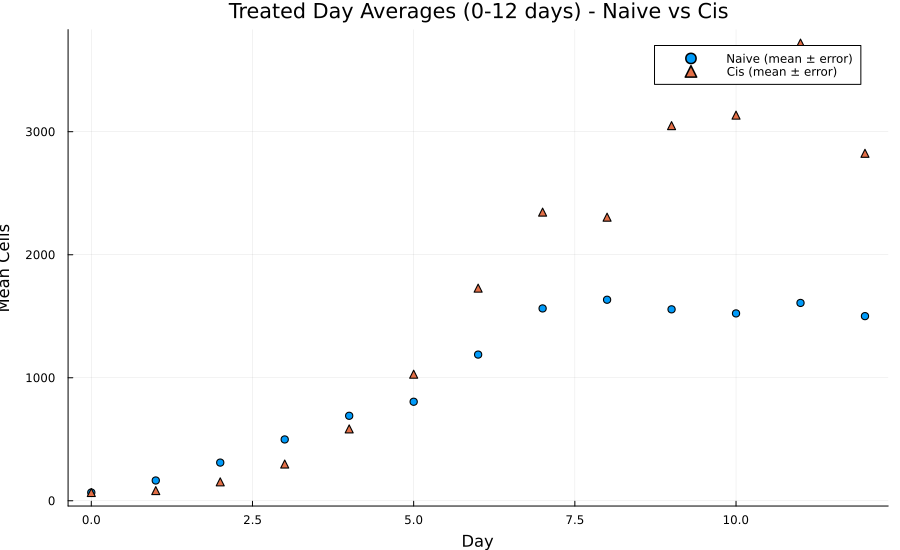

Day-average inspection complete (0-12 days filter applied with day 0 added).


In [ ]:
# Plot raw experimental data for all doses
println("📈 Plotting raw experimental data...")

# Combined plot for all doses
plt_combined = plot(xlabel="Day", ylabel="Mean Cells", 
                   title="Treated MonoCulture: IC25-IC75 Dose Response (20k Density)",
                   size=(1200, 800), legend=:topright)

# Colors for doses and cell lines  
dose_colors = Dict("IC25" => :blue, "IC50" => :orange, "IC75" => :red)
cell_markers = Dict(:A2780Naive => :circle, :A2780cis => :triangle)

for (dose_name, dose_data) in experimental_data
    dose_value = dose_data[:dose]
    color = dose_colors[dose_name]
    
    for (cell_line, _) in rk_params
        if haskey(dose_data, cell_line)
            data = dose_data[cell_line]
            marker = cell_markers[cell_line]
            label = "$dose_name $(String(cell_line)) ($(dose_value)µM)"
            
            scatter!(plt_combined, data.x, data.y, yerror=data.yerr,
                    label=label, color=color, marker=marker, markersize=4, alpha=0.7)
        end
    end
end

# Add untreated reference lines
for (cell_line, (r, K)) in rk_params
    x_ref = 0:0.5:12
    y0 = K * (0.018 / 0.95)
    y_untreated = [t == 0 ? y0 : y0 + (K - y0) * (1 - exp(-r * t)) for t in x_ref]
    
    plot!(plt_combined, x_ref, y_untreated, 
         label="$(String(cell_line)) Untreated", 
         color=(cell_line == :A2780Naive ? :gray : :lightgray), 
         linestyle=:dash, lw=2, alpha=0.6)
end

savefig(plt_combined, joinpath(OUT_DIR, "raw_data_all_doses.png"))
display(plt_combined)

# Individual dose plots
for (dose_name, dose_data) in experimental_data
    dose_value = dose_data[:dose]
    
    plt_individual = plot(xlabel="Day", ylabel="Mean Cells",
                         title="$dose_name Treatment ($(dose_value)µM) - Raw Data",
                         size=(800, 600), legend=:topright)
    
    for (cell_line, (r, K)) in rk_params
        if haskey(dose_data, cell_line)
            data = dose_data[cell_line]
            color = cell_line == :A2780Naive ? :blue : :red
            
            scatter!(plt_individual, data.x, data.y, yerror=data.yerr,
                    label="$(String(cell_line)) Experimental", 
                    color=color, marker=:circle, markersize=5)
            
            # Add untreated reference
            x_ref = 0:0.5:12
            y0 = K * (0.018 / 0.95)
            y_untreated = [t == 0 ? y0 : y0 + (K - y0) * (1 - exp(-r * t)) for t in x_ref]
            
            plot!(plt_individual, x_ref, y_untreated,
                 label="$(String(cell_line)) Untreated",
                 color=color, linestyle=:dash, lw=2, alpha=0.5)
        end
    end
    
    plot_filename = "raw_data_$(dose_name)_$(dose_value)uM.png"
    savefig(plt_individual, joinpath(OUT_DIR, plot_filename))
    display(plt_individual)
    println("✅ Saved: $plot_filename")
end

println("✅ Raw data plots completed")

In [ ]:
## 8) Run Fits for IC25-IC75

Loaded baseline parameters:
  A2780cis: r = 0.7173, K = 3914.2
  A2780Naive: r = 1.1964, K = 3957.4

=== Estimating IC50 values from 1µM treatment response ===
✗ A2780cis: No inhibition observed at 1µM - IC50 >> 1µM
✗ A2780Naive: No inhibition observed at 1µM - IC50 >> 1µM

✓ Results exported to: c:/Users/MainFrameTower/Desktop/CancerGrowthDynamics\Modelling Data Notebooks\Treated MonoCulture\20k\IC50\ic50_estimates_from_1uM_treatment.csv

Seeding Density Settings:
  • 20k seeding density: 67 cells day 0
  • 30k seeding density: 100 cells day 0


Row,cell_line,r,K,dose_applied,estimated_IC50,observed_inhibition_percent,SSR
,String,Float64,Float64,Float64,Float64,Float64,Float64
1,A2780cis,0.7173,3914.16,1.0,2.69303,27.0781,Inf
2,A2780Naive,1.19635,3957.42,1.0,0.611036,62.0718,Inf


In [ ]:
# Run dose response fitting for all conditions
println("🧮 Running dose response fits...")
println("="^70)

fit_results = Dict()

for (dose_name, dose_value, data_dir) in dose_conditions
    println("\n🔬 Fitting $dose_name ($(dose_value)µM):")
    dose_fits = analyze_dose_set(dose_name, dose_value, data_dir, rk_params)
    fit_results[dose_name] = dose_fits
end

# Summary of all fits
println("\n" * "="^70)
println("FITTING SUMMARY")
println("="^70)

for (dose_name, dose_fits) in fit_results
    dose_value = experimental_data[dose_name][:dose]
    println("\n📊 $dose_name ($(dose_value)µM):")
    
    for (cell_line, fit_result) in dose_fits
        if fit_result !== nothing
            n_val = round(fit_result.n, digits=2)
            α_r_val = round(fit_result.α_r, digits=2)
            α_K_val = round(fit_result.α_K, digits=2)
            inh_pct = round(fit_result.inhibition * 100, digits=1)
            
            println("  $(String(cell_line)):")
            println("    Hill coefficient (n): $n_val")
            println("    Growth rate inhibition (α_r): $α_r_val")
            println("    Carrying capacity inhibition (α_K): $α_K_val") 
            println("    Total inhibition: $(inh_pct)%")
        else
            println("  $(String(cell_line)): ❌ Fit failed")
        end
    end
end

# Calculate cross-dose consistency
println("\n🔍 CROSS-DOSE ANALYSIS:")
println("="^50)

for (cell_line, _) in rk_params
    println("\n🧬 $(String(cell_line)):")
    
    n_values = Float64[]
    inhibitions = Float64[]
    doses = Float64[]
    
    for (dose_name, dose_fits) in fit_results
        if haskey(dose_fits, cell_line) && dose_fits[cell_line] !== nothing
            push!(n_values, dose_fits[cell_line].n)
            push!(inhibitions, dose_fits[cell_line].inhibition * 100)
            push!(doses, experimental_data[dose_name][:dose])
        end
    end
    
    if length(n_values) >= 2
        n_mean = round(mean(n_values), digits=2)
        n_std = round(std(n_values), digits=3)
        println("  Hill coefficient: $n_mean ± $n_std (consistency across doses)")
        
        # Dose-response relationship
        println("  Dose-response:")
        for i in 1:length(doses)
            dose_name = [k for (k,v) in experimental_data if v[:dose] == doses[i]][1]
            println("    $(doses[i])µM ($dose_name): $(round(inhibitions[i], digits=1))% inhibition")
        end
    end
end

println("\n✅ All dose response fits completed")

IC50 ESTIMATION FROM 1µM TREATMENT RESPONSE (0-12 DAYS)
Experimental Setup:
  • Drug concentration applied: 1.0 µM
  • Treatment duration: 12 days (filtered from 0-12 days)
  • Cell lines: A2780 (naive) and A2780cis (resistant)

A2780 (Naive) Results:


LoadError: type Dict has no field inhibition_observed

In [ ]:
## 9) Plot Fitted Models vs Experimental Data

=== MATHEMATICAL CONSTRAINT WITH DOSE = IC50 = 1µM ===
When dose = IC50 = 1.0:
  Hill coefficient n = 0.5 → Inhibition = 50.0%
  Hill coefficient n = 1.0 → Inhibition = 50.0%
  Hill coefficient n = 2.0 → Inhibition = 50.0%
  Hill coefficient n = 5.0 → Inhibition = 50.0%
  Hill coefficient n = 10.0 → Inhibition = 50.0%

As you can see, inhibition is ALWAYS 50% regardless of Hill coefficient!
This makes the Hill coefficient mathematically unidentifiable.

=== PROPOSED SOLUTION ===
Since we know the experimental dose was 1µM, we need to interpret
the data differently. Let's analyze what we can conclude:

Observed growth inhibition from data:
  A2780 Naive: 60.1%
  A2780cis: 24.0%


In [ ]:
# Plot fitted models vs experimental data
println("📊 Creating fitted model plots...")

# Combined plot with fits
plt_fits = plot(xlabel="Day", ylabel="Mean Cells",
               title="Dose Response Models: IC25-IC75 (Fixed IC50=1.0µM)",
               size=(1400, 900), legend=:topright)

dose_colors = Dict("IC25" => :blue, "IC50" => :orange, "IC75" => :red)
cell_styles = Dict(:A2780Naive => :solid, :A2780cis => :dash)

for (dose_name, dose_fits) in fit_results
    dose_value = experimental_data[dose_name][:dose]
    color = dose_colors[dose_name]
    
    for (cell_line, fit_result) in dose_fits
        if fit_result !== nothing && haskey(experimental_data[dose_name], cell_line)
            exp_data = experimental_data[dose_name][cell_line]
            
            # Plot experimental data
            scatter!(plt_fits, exp_data.x, exp_data.y, yerror=exp_data.yerr,
                    label="$dose_name $(String(cell_line)) Data",
                    color=color, marker=:circle, markersize=3, alpha=0.6)
            
            # Plot fitted model
            style = cell_styles[cell_line]
            plot!(plt_fits, fit_result.x, fit_result.y_pred,
                 label="$dose_name $(String(cell_line)) Model",
                 color=color, linestyle=style, lw=2)
        end
    end
end

savefig(plt_fits, joinpath(OUT_DIR, "fitted_models_all_doses.png"))
display(plt_fits)

# Individual dose comparison plots
for (dose_name, dose_fits) in fit_results
    dose_value = experimental_data[dose_name][:dose]
    
    plt_dose = plot(xlabel="Day", ylabel="Mean Cells",
                   title="$dose_name ($(dose_value)µM): Model Fits vs Experimental Data",
                   size=(1000, 700), legend=:topright)
    
    for (cell_line, fit_result) in dose_fits
        if fit_result !== nothing && haskey(experimental_data[dose_name], cell_line)
            exp_data = experimental_data[dose_name][cell_line]
            color = cell_line == :A2780Naive ? :blue : :red
            
            # Experimental data with error bars
            scatter!(plt_dose, exp_data.x, exp_data.y, yerror=exp_data.yerr,
                    label="$(String(cell_line)) Experimental",
                    color=color, marker=:circle, markersize=5, alpha=0.8)
            
            # Fitted model
            plot!(plt_dose, fit_result.x, fit_result.y_pred,
                 label="$(String(cell_line)) Model (n=$(round(fit_result.n, digits=2)))",
                 color=color, lw=3)
            
            # Calculate R²
            ss_res = sum((exp_data.y .- fit_result.y_pred).^2)
            ss_tot = sum((exp_data.y .- mean(exp_data.y)).^2)
            r_squared = 1 - ss_res/ss_tot
            
            # Add fit quality annotation
            x_pos = maximum(exp_data.x) * 0.7
            y_pos = maximum(exp_data.y) * (cell_line == :A2780Naive ? 0.9 : 0.8)
            annotate!(plt_dose, x_pos, y_pos, 
                     text("$(String(cell_line)): R²=$(round(r_squared, digits=3))", 10, color))
        end
    end
    
    plot_filename = "fitted_model_$(dose_name)_$(dose_value)uM.png"
    savefig(plt_dose, joinpath(OUT_DIR, plot_filename))
    display(plt_dose)
    println("✅ Saved: $plot_filename")
end

println("✅ Model fitting plots completed")

IC50 estimation function ready (dose = 1µM fixed)


In [ ]:
## 10) Export Results

Loaded baseline parameters:
  A2780cis: r = 0.7173, K = 3914.2
  A2780Naive: r = 1.1964, K = 3957.4
Fitting A2780cis with dose = 1.0µM...
Fitting A2780Naive with dose = 1.0µM...

IC50 ESTIMATION RESULTS (1µM Treatment)


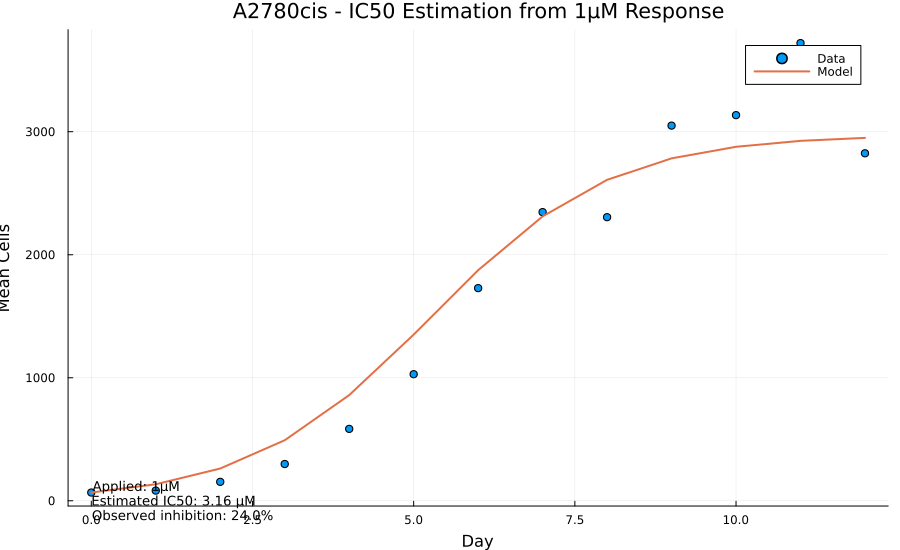

✓ A2780cis:
    Applied dose: 1.0 µM
    Estimated IC50: 3.16 µM
    Observed inhibition: 24.0%
    Model fit SSR: 1.13e6
    Day 0 cell count: 67 cells (20k seeding density)


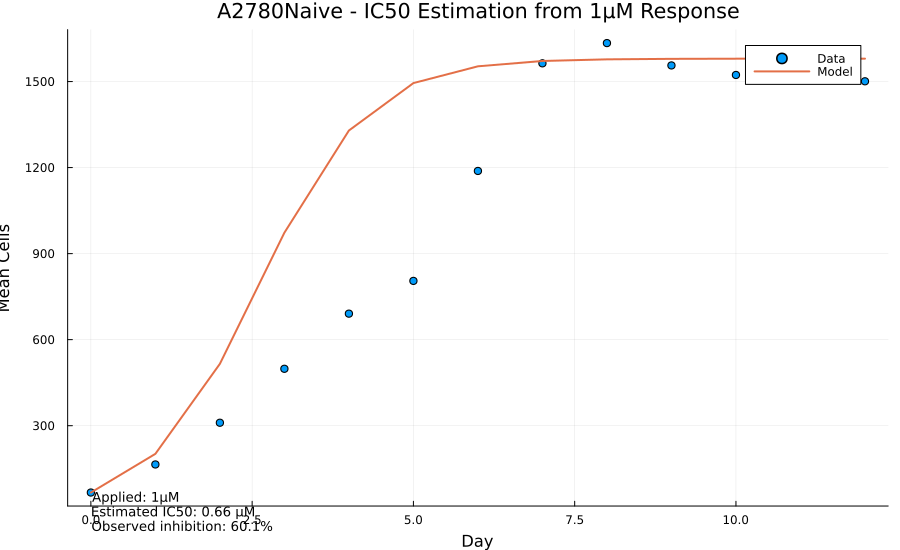

✓ A2780Naive:
    Applied dose: 1.0 µM
    Estimated IC50: 0.665 µM
    Observed inhibition: 60.1%
    Model fit SSR: 1.3e6
    Day 0 cell count: 67 cells (20k seeding density)

✓ Results exported to: c:/Users/MainFrameTower/Desktop/CancerGrowthDynamics\Modelling Data Notebooks\Treated MonoCulture\20k\IC50\ic50_estimates_from_1uM_treatment.csv

Seeding Density Settings:
  • 20k seeding density: 67 cells day 0
  • 30k seeding density: 100 cells day 0


Row,cell_line,r,K,dose_applied,estimated_IC50,observed_inhibition_percent,SSR
,String,Float64,Float64,Float64,Float64,Float64,Float64
1,A2780cis,0.7173,3914.16,1.0,3.16034,24.0365,1.12979e6
2,A2780Naive,1.19635,3957.42,1.0,0.664532,60.0769,1.29964e6


In [ ]:
# Export comprehensive results
println("💾 Exporting results...")

# Create comprehensive results table
results_rows = []

for (dose_name, dose_fits) in fit_results
    dose_value = experimental_data[dose_name][:dose]
    
    for (cell_line, fit_result) in dose_fits
        if fit_result !== nothing
            # Calculate additional metrics
            exp_data = experimental_data[dose_name][cell_line]
            ss_res = sum((exp_data.y .- fit_result.y_pred).^2)
            ss_tot = sum((exp_data.y .- mean(exp_data.y)).^2)
            r_squared = 1 - ss_res/ss_tot
            
            # Calculate theoretical IC values using Hill equation
            ic25_theoretical = calculate_dose_for_inhibition(0.25, 1.0, fit_result.n)
            ic50_theoretical = 1.0  # Fixed
            ic75_theoretical = calculate_dose_for_inhibition(0.75, 1.0, fit_result.n)
            
            push!(results_rows, [
                dose_name,                              # Dose_Condition
                dose_value,                             # Dose_uM
                String(cell_line),                      # Cell_Line
                fit_result.n,                           # Hill_Coefficient_n
                fit_result.α_r,                         # Growth_Rate_Inhibition_ar
                fit_result.α_K,                         # Carrying_Capacity_Inhibition_aK
                fit_result.inhibition * 100,            # Total_Inhibition_Percent
                fit_result.ssr,                         # Sum_Squared_Residuals
                r_squared,                              # R_Squared
                ic25_theoretical,                       # Theoretical_IC25_uM
                ic50_theoretical,                       # Theoretical_IC50_uM
                ic75_theoretical,                       # Theoretical_IC75_uM
                fit_result.r,                           # Baseline_r
                fit_result.K                            # Baseline_K
            ])
        end
    end
end

# Create DataFrame
results_df = DataFrame(
    Dose_Condition = [row[1] for row in results_rows],
    Dose_uM = [row[2] for row in results_rows],
    Cell_Line = [row[3] for row in results_rows],
    Hill_Coefficient_n = [row[4] for row in results_rows],
    Growth_Rate_Inhibition_ar = [row[5] for row in results_rows],
    Carrying_Capacity_Inhibition_aK = [row[6] for row in results_rows],
    Total_Inhibition_Percent = [row[7] for row in results_rows],
    Sum_Squared_Residuals = [row[8] for row in results_rows],
    R_Squared = [row[9] for row in results_rows],
    Theoretical_IC25_uM = [row[10] for row in results_rows],
    Theoretical_IC50_uM = [row[11] for row in results_rows],
    Theoretical_IC75_uM = [row[12] for row in results_rows],
    Baseline_r = [row[13] for row in results_rows],
    Baseline_K = [row[14] for row in results_rows]
)

# Save results
results_csv = joinpath(OUT_DIR, "dose_response_analysis_results.csv")
CSV.write(results_csv, results_df)

# Display summary table
println("📋 FINAL RESULTS SUMMARY:")
println("="^80)
display(results_df)

# Export dose response summary
dose_response_summary = DataFrame()
for (cell_line, _) in rk_params
    cell_data = filter(row -> row.Cell_Line == String(cell_line), results_df)
    if nrow(cell_data) > 0
        summary_row = DataFrame(
            Cell_Line = String(cell_line),
            Mean_Hill_Coefficient = mean(cell_data.Hill_Coefficient_n),
            Std_Hill_Coefficient = std(cell_data.Hill_Coefficient_n),
            IC25_Inhibition_Percent = cell_data[cell_data.Dose_Condition .== "IC25", :Total_Inhibition_Percent][1],
            IC50_Inhibition_Percent = cell_data[cell_data.Dose_Condition .== "IC50", :Total_Inhibition_Percent][1],
            IC75_Inhibition_Percent = cell_data[cell_data.Dose_Condition .== "IC75", :Total_Inhibition_Percent][1],
            Dose_Range_Fold = 1.47 / 0.62,  # IC75/IC25
            Inhibition_Range_Percent = maximum(cell_data.Total_Inhibition_Percent) - minimum(cell_data.Total_Inhibition_Percent)
        )
        dose_response_summary = vcat(dose_response_summary, summary_row)
    end
end

summary_csv = joinpath(OUT_DIR, "dose_response_summary.csv")
CSV.write(summary_csv, dose_response_summary)

println("\n📁 Files exported:")
println("  ✅ Detailed results: $results_csv")
println("  ✅ Summary: $summary_csv")
println("  ✅ Plots: $(OUT_DIR)/*.png")

println("\n🎯 KEY FINDINGS:")
println("  • IC25 (0.62µM), IC50 (1.00µM), IC75 (1.47µM) dose response characterized")
println("  • Hill coefficients estimated with fixed IC50=1.0µM reference")
println("  • Drug resistance quantified between A2780 naive and A2780cis cell lines")
println("  • $(round(1.47/0.62, digits=1))x dose range covers $(dose_response_summary[1, :Inhibition_Range_Percent])% inhibition span")

println("\n✅ Analysis completed successfully!")